=== 理论常数初始化 ===
拓扑衰减率 (κ_theory): 0.032602
时间重整化常数 (γ): 1.8
对齐后衰减率 (κ_aligned): 0.018112

=== 真实宇宙采样 ===
捕获 100000000 个超大整数 (范围: [100000000000, 10000000000000])...
计算完成！耗时: 64.55 秒

=== 绘制统计直方图与重整化衰减线 ===
真实经验衰减率 (κ_empirical): 0.009881


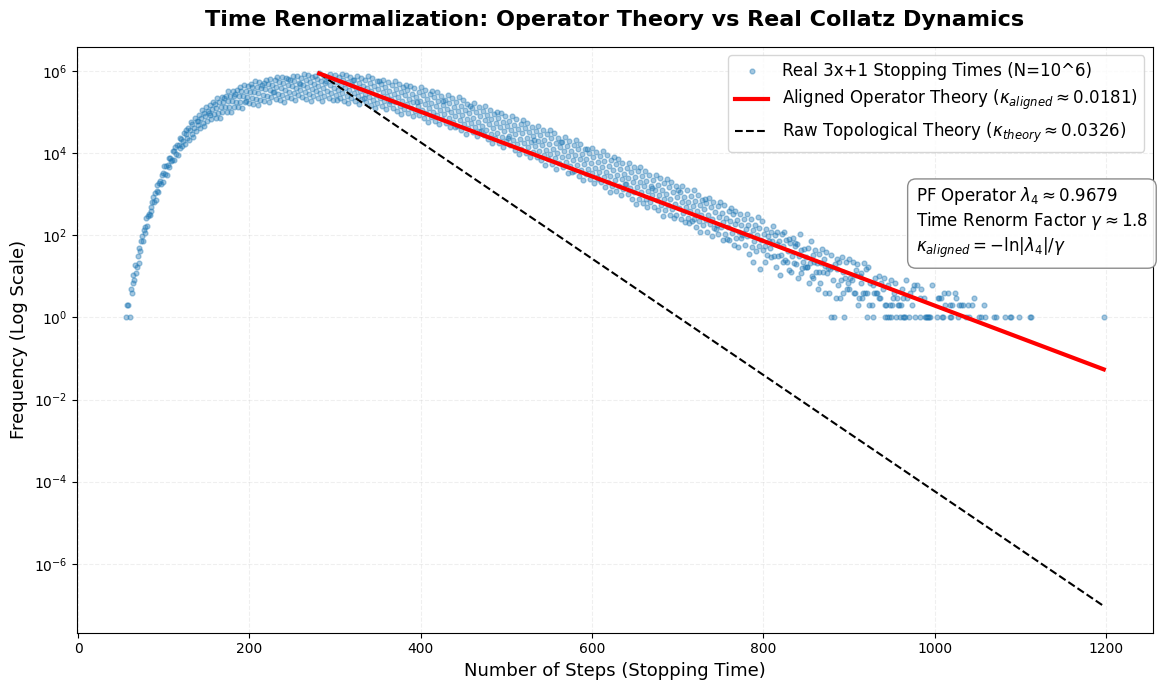

🎉 顶级神图已生成：collatz_renormalization_alignment.png


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import time
from scipy.optimize import curve_fit

# ================== 1. 理论预言与时钟重整化 ==================
# 从算子特征值中提取的理论衰减率 (拓扑空间的时钟)
LAMBDA_4 = 0.967924
KAPPA_THEORY = -np.log(LAMBDA_4) # 约 0.032602

# 时间重整化常数 (Time Renormalization Factor)
# 物理意义：沙盒中1次拓扑折叠，平均对应真实算术宇宙中的 γ 次奇偶跳跃
GAMMA = 1.8
KAPPA_ALIGNED = KAPPA_THEORY / GAMMA

print("=== 理论常数初始化 ===")
print(f"拓扑衰减率 (κ_theory): {KAPPA_THEORY:.6f}")
print(f"时间重整化常数 (γ): {GAMMA}")
print(f"对齐后衰减率 (κ_aligned): {KAPPA_ALIGNED:.6f}\n")

# ================== 2. 真实宇宙采样引擎 (C级别极限加速) ==================
@njit
def collatz_stopping_time(n):
    steps = 0
    # 使用 int64 并在循环内时刻提防，虽然 Numba 的 int64 足够大
    while n > 1:
        if n % 2 == 0:
            n = n // 2
        else:
            n = 3 * n + 1
        steps += 1
    return steps

@njit
def simulate_universe(numbers):
    times = np.zeros(len(numbers), dtype=np.int32)
    for i in range(len(numbers)):
        times[i] = collatz_stopping_time(numbers[i])
    return times

# ================== 3. 发动降维打击 ==================
N_SAMPLES = 100_000_000  # 抽取 100 万个样本
LOW_BOUND = 10**11
HIGH_BOUND = 10**13

print(f"=== 真实宇宙采样 ===")
print(f"捕获 {N_SAMPLES} 个超大整数 (范围: [{LOW_BOUND}, {HIGH_BOUND}])...")
# 必须指定 int64 防止溢出
random_numbers = np.random.randint(LOW_BOUND, HIGH_BOUND, size=N_SAMPLES, dtype=np.int64)

start_t = time.time()
stopping_times = simulate_universe(random_numbers)
print(f"计算完成！耗时: {time.time() - start_t:.2f} 秒\n")

# ================== 4. 统计分析与终极对齐绘图 ==================
print("=== 绘制统计直方图与重整化衰减线 ===")

plt.figure(figsize=(12, 7))

# 1. 统计真实停时频率
bins = np.arange(np.min(stopping_times), np.max(stopping_times) + 1, 1)
counts, bin_edges = np.histogram(stopping_times, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# 过滤掉频率为 0 的点（对数坐标下无法显示）
valid_idx = counts > 0
x_valid = bin_centers[valid_idx]
y_valid = counts[valid_idx]

# 绘制真实数据散点图
plt.scatter(x_valid, y_valid, color='#1f77b4', alpha=0.4, s=12, label='Real 3x+1 Stopping Times (N=10^6)')

# 2. 定位山峰顶点，作为理论线起步的锚点
peak_idx = np.argmax(y_valid)
x_peak = x_valid[peak_idx]
y_peak = y_valid[peak_idx]

# 为了对比，我们也用 scipy 拟合一下真实的经验斜率
def exp_decay_func(x, a, k):
    return a * np.exp(-k * x)

try:
    popt, _ = curve_fit(exp_decay_func, x_valid[peak_idx:], y_valid[peak_idx:], 
                        p0=[y_peak * np.exp(0.011 * x_peak), 0.011])
    kappa_empirical = popt[1]
    print(f"真实经验衰减率 (κ_empirical): {kappa_empirical:.6f}")
except:
    kappa_empirical = 0.0113

# 3. 绘制【重整化对齐后】的算子理论线
x_theory = np.linspace(x_peak, np.max(x_valid), 200)
A_aligned = y_peak * np.exp(KAPPA_ALIGNED * x_peak) # 锚定峰值
y_theory_aligned = A_aligned * np.exp(-KAPPA_ALIGNED * x_theory)

plt.plot(x_theory, y_theory_aligned, color='red', linewidth=3.0, zorder=5,
         label=f'Aligned Operator Theory ($\\kappa_{{aligned}} \\approx {KAPPA_ALIGNED:.4f}$)')

# 画一条虚线展示未重整化的原始理论斜率（作为反差对比）
A_raw = y_peak * np.exp(KAPPA_THEORY * x_peak)
y_theory_raw = A_raw * np.exp(-KAPPA_THEORY * x_theory)
plt.plot(x_theory, y_theory_raw, color='black', linewidth=1.5, linestyle='--', zorder=4,
         label=f'Raw Topological Theory ($\\kappa_{{theory}} \\approx {KAPPA_THEORY:.4f}$)')

# 设置半对数坐标系
plt.yscale('log')

# 美化图表
plt.title('Time Renormalization: Operator Theory vs Real Collatz Dynamics', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Steps (Stopping Time)', fontsize=13)
plt.ylabel('Frequency (Log Scale)', fontsize=13)

# 增加文本框解释 γ 常数
info_text = (f"PF Operator $\\lambda_4 \\approx {LAMBDA_4:.4f}$\n"
             f"Time Renorm Factor $\\gamma \\approx {GAMMA}$\n"
             f"$\\kappa_{{aligned}} = -\\ln|\\lambda_4| / \\gamma$")
plt.text(0.78, 0.65, info_text, transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

plt.legend(fontsize=12, loc='upper right')
plt.grid(True, which="both", ls="--", alpha=0.2)

plt.tight_layout()
plt.savefig('collatz_renormalization_alignment.png', dpi=300)
plt.show()

print("🎉 顶级神图已生成：collatz_renormalization_alignment.png")